# Problem 1

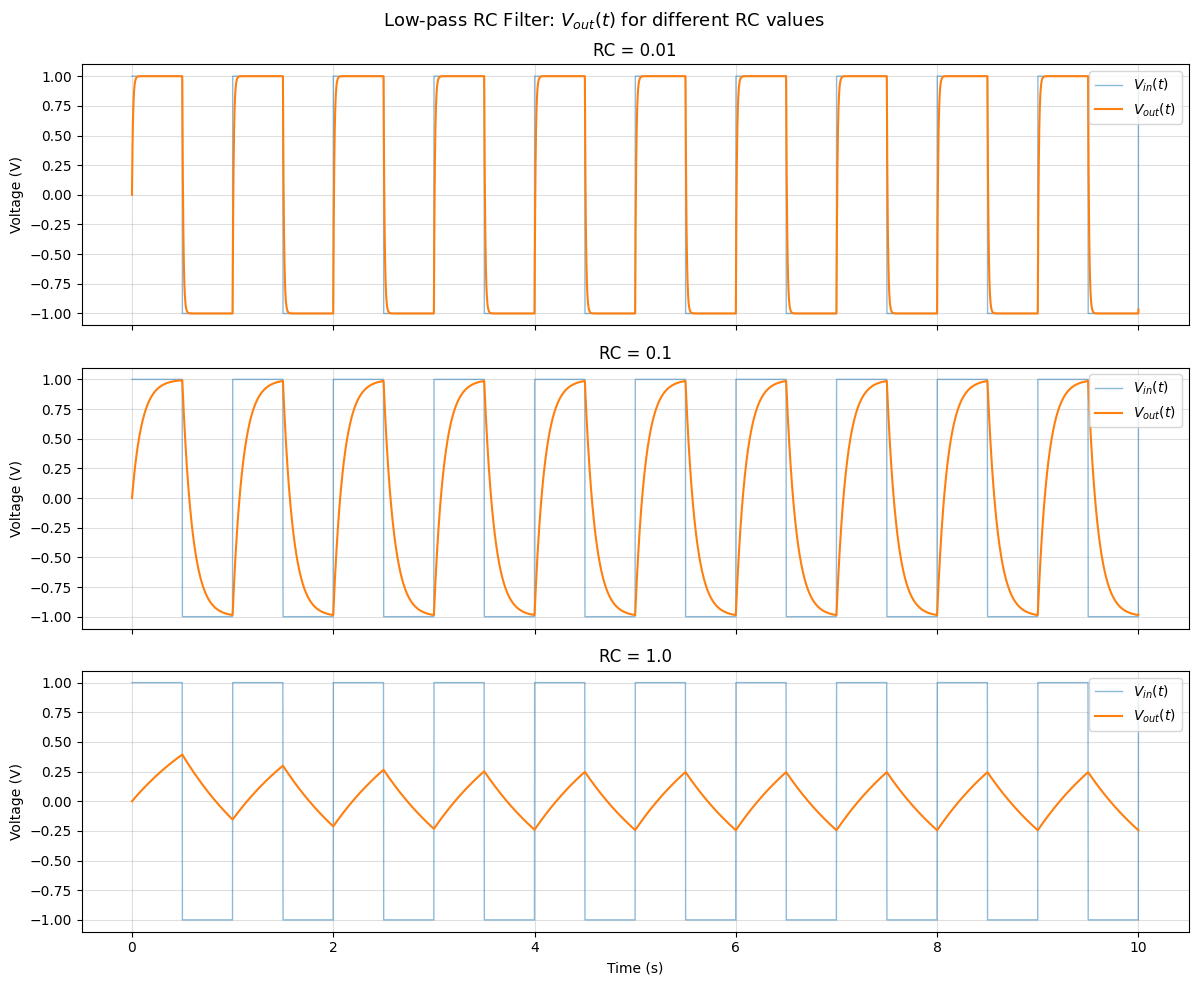

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Square wave input
def V_in(t):
    if int(2 * t) % 2 == 0:
        return 1.0
    else:
        return -1.0

# RHS of ODE: dVout/dt = (Vin - Vout) / RC
def f(Vout, t, RC):
    return (V_in(t) - Vout) / RC

# 4th order Runge-Kutta solver
def rk4(RC, h=0.001, t_start=0.0, t_end=10.0):
    t_vals = np.arange(t_start, t_end + h, h)
    Vout = np.zeros(len(t_vals))
    Vout[0] = 0.0  # Initial condition Vout(0) = 0

    for i in range(len(t_vals) - 1):
        t = t_vals[i]
        V = Vout[i]

        k1 = h * f(V,          t,       RC)
        k2 = h * f(V + k1/2,   t + h/2, RC)
        k3 = h * f(V + k2/2,   t + h/2, RC)
        k4 = h * f(V + k3,     t + h,   RC)

        Vout[i+1] = V + (k1 + 2*k2 + 2*k3 + k4) / 6

    return t_vals, Vout

h = 0.001
t_plot = np.arange(0, 10 + h, h)
Vin_plot = np.array([V_in(t) for t in t_plot])

RC_values = [0.01, 0.1, 1.0]

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for ax, RC in zip(axes, RC_values):
    t_vals, Vout = rk4(RC, h=h)
    ax.plot(t_vals, Vin_plot, lw=1, alpha=0.5, label=r'$V_{in}(t)$')
    ax.plot(t_vals, Vout, lw=1.5, label=r'$V_{out}(t)$')
    ax.set_ylabel('Voltage (V)')
    ax.set_title(f'RC = {RC}')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.4)

axes[-1].set_xlabel('Time (s)')
plt.suptitle('Low-pass RC Filter: $V_{out}(t)$ for different RC values', fontsize=13)
plt.tight_layout()
plt.show()

### 1b

The circuit acts as a **low-pass filter**. It allows slow-varying (low frequency) signals to pass through while suppressing fast-varying (high frequency) components. The behavior depends strongly on the value of RC:

- **RC = 0.01**: The time constant is very small, so the capacitor charges and discharges almost instantly. V_out closely tracks V_in and the output looks nearly identical to the input square wave.

- **RC = 0.1**: The time constant is comparable to the half-period of the square wave (0.5 s). The capacitor cannot fully charge or discharge before V_in switches, so V_out shows a smoothed, rounded version of the square wave (the sharp edges are replaced by exponential rises and falls)

- **RC = 1**: The time constant is much larger than the period of the input. The capacitor barely has time to respond before V_in flips sign. As a result, V_out is heavily smoothed and the oscillations are greatly reduced in amplitude (the high-frequency content of the square wave is almost entirely filtered out)

In summary, larger RC suppresses the output more, as the circuit increasingly averages out the fast fluctuations in the input signal. 

# Problem 2

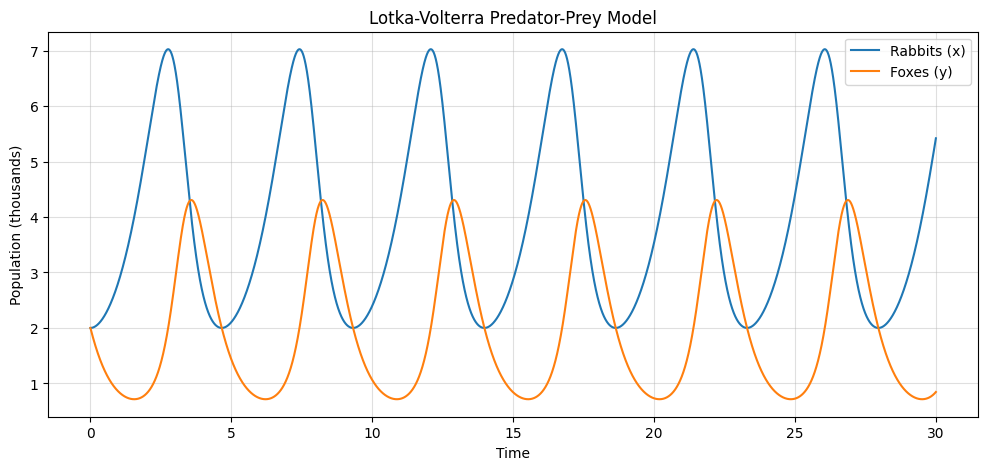

In [2]:
# 2a

alpha = 1.0
beta  = 0.5
gamma = 0.5
delta = 2.0

def f(r, t):
    x, y = r
    dxdt = alpha*x - beta*x*y
    dydt = gamma*x*y - delta*y
    return np.array([dxdt, dydt])

def rk4(f, r0, t_start, t_end, h):
    t_vals = np.arange(t_start, t_end + h, h)
    r_vals = np.zeros((len(t_vals), len(r0)))
    r_vals[0] = r0

    for i in range(len(t_vals) - 1):
        t = t_vals[i]
        r = r_vals[i]

        k1 = h * f(r,t)
        k2 = h * f(r + k1/2, t + h/2)
        k3 = h * f(r + k2/2, t + h/2)
        k4 = h * f(r + k3, t + h)

        r_vals[i+1] = r + (k1 + 2*k2 + 2*k3 + k4) / 6

    return t_vals, r_vals

r0 = np.array([2.0, 2.0])  #Intitial Condition
h  = 0.001

t_vals, r_vals = rk4(f, r0, t_start=0.0, t_end=30.0, h=h)

x_vals = r_vals[:, 0] 
y_vals = r_vals[:, 1] 

plt.figure(figsize=(12, 5))
plt.plot(t_vals, x_vals, label='Rabbits (x)')
plt.plot(t_vals, y_vals, label='Foxes (y)')
plt.xlabel('Time')
plt.ylabel('Population (thousands)')
plt.title('Lotka-Volterra Predator-Prey Model')
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

### 2b

The plot shows that both populations oscillate periodically over time. The system exhibits the classic predator-prey cycle:

- When the rabbit population is large, foxes have plenty of food and their population grows.
- As the fox population rises, they eat more rabbits, causing the rabbit population to fall.
- With fewer rabbits available, the foxes start to starve and their population drops.
- With fewer foxes preying on them, the rabbits recover and their population rises again.

This cycle then repeats indefinitely. Notice that the fox population always **lags behind** the rabbit population i.e. the peaks in foxes come slightly after the peaks in rabbits, which makes physical sense since the foxes need time to grow in response to abundant food.

# Problem 3

In [3]:
sigma = 10.0
r = 28.0
b = 8/3

def f(r_vec, t):
    x, y, z = r_vec
    dxdt = sigma * (y - x)
    dydt = r*x - y - x*z
    dzdt = x*y - b*z
    return np.array([dxdt, dydt, dzdt])

def rk4(f, r0, t_start, t_end, h):
    t_vals = np.arange(t_start, t_end + h, h)
    r_vals = np.zeros((len(t_vals), len(r0)))
    r_vals[0] = r0

    for i in range(len(t_vals) - 1):
        t = t_vals[i]
        r = r_vals[i]

        k1 = h * f(r,t)
        k2 = h * f(r + k1/2, t + h/2)
        k3 = h * f(r + k2/2, t + h/2)
        k4 = h * f(r + k3, t + h)

        r_vals[i+1] = r + (k1 + 2*k2 + 2*k3 + k4) / 6

    return t_vals, r_vals

r0 = np.array([0.0, 1.0, 0.0])  # Initial Condition
h  = 0.001

t_vals, r_vals = rk4(f, r0, t_start=0.0, t_end=50.0, h=h)
x_vals = r_vals[:, 0]
y_vals = r_vals[:, 1]
z_vals = r_vals[:, 2]

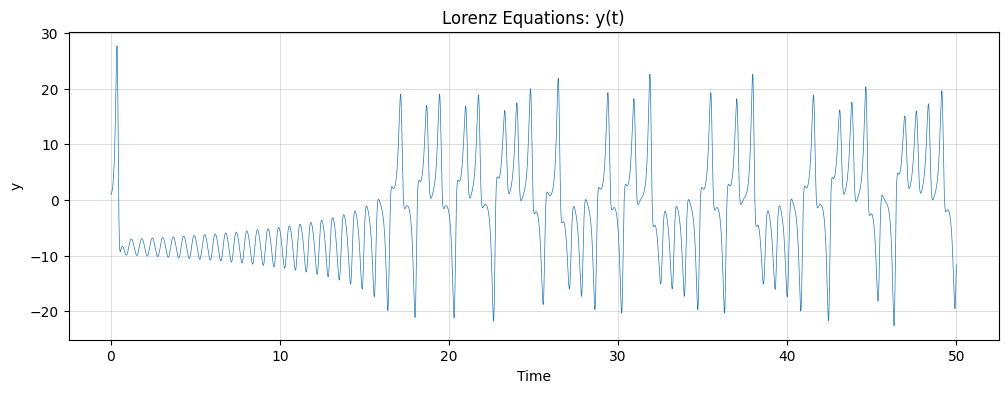

In [4]:
# Part a
plt.figure(figsize=(12, 4))
plt.plot(t_vals, y_vals, lw=0.5)
plt.xlabel('Time')
plt.ylabel('y')
plt.title('Lorenz Equations: y(t)')
plt.grid(True, alpha=0.4)
plt.show()

The motion is non-periodic and sensitive to initial conditions, demonstrating deterministic chaos

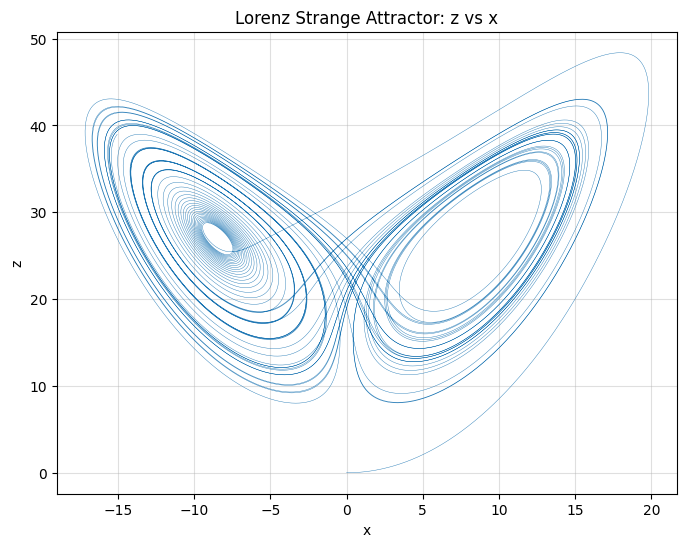

In [5]:
# Part b
plt.figure(figsize=(8, 6))
plt.plot(x_vals, z_vals, lw=0.3)
plt.xlabel('x')
plt.ylabel('z')
plt.title('Lorenz Strange Attractor: z vs x')
plt.grid(True, alpha=0.4)
plt.show()

# Problem 4

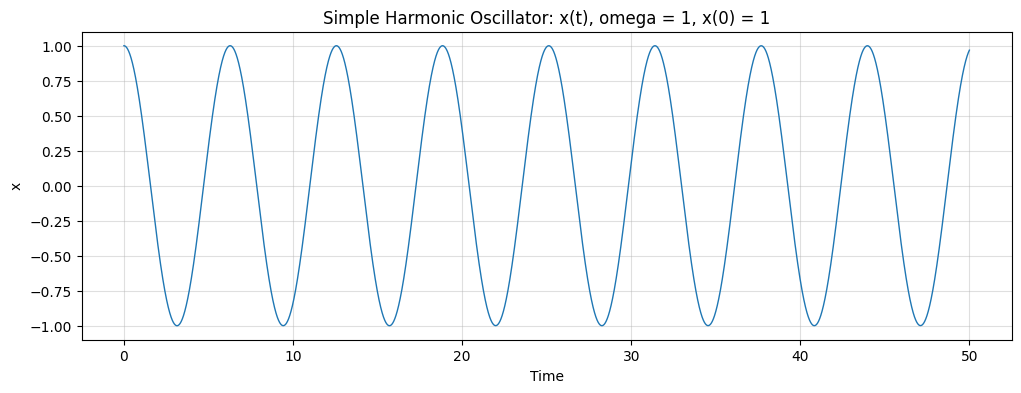

In [6]:
# 4a 


import scipy

omega = 1.0
# dx/dt = v, dv/dt = -omega^2 * x
def f(t, r):
    x, v = r
    return [v, -omega**2 * x]

t_eval = np.linspace(0, 50, 50000)

sol = scipy.integrate.solve_ivp(f, [0, 50], [1.0, 0.0], t_eval=t_eval, dense_output=True, method="RK45")

plt.figure(figsize=(12, 4))
plt.plot(sol.t, sol.y[0], lw=1)
plt.xlabel('Time')
plt.ylabel('x')
plt.title('Simple Harmonic Oscillator: x(t), omega = 1, x(0) = 1')
plt.grid(True, alpha=0.4)
plt.show()

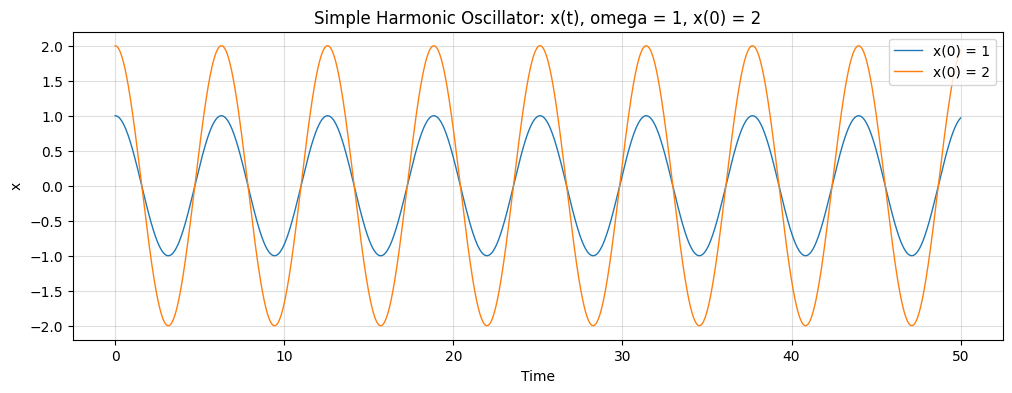

In [7]:
# 4b

omega = 1.0
def f(t, r):
    x, v = r
    return [v, -omega**2 * x]

t_eval = np.linspace(0, 50, 50000)

sol2 = scipy.integrate.solve_ivp(f, [0, 50], [2.0, 0.0], t_eval=t_eval, dense_output=True, method="RK45")

plt.figure(figsize=(12, 4))
plt.plot(sol.t, sol.y[0], lw=1, label='x(0) = 1')
plt.plot(sol2.t, sol2.y[0], lw=1, label='x(0) = 2')
plt.xlabel('Time')
plt.ylabel('x')
plt.title('Simple Harmonic Oscillator: x(t), omega = 1, x(0) = 2')
plt.grid(True, alpha=0.4)
plt.legend()
plt.show()

Therefore we can see that the frequency is same for both

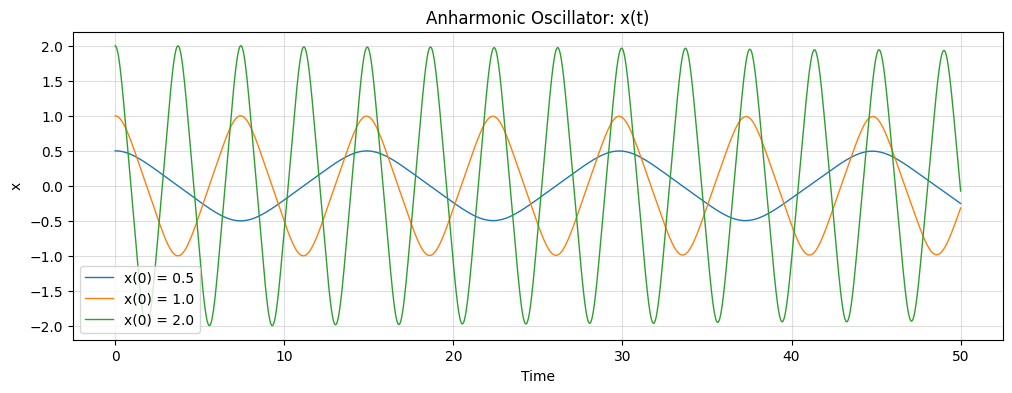

In [8]:
# 4c

omega = 1.0

# dx/dt = v, dv/dt = -omega^2 * x^3
def f(t, r):
    x, v = r
    return [v, -omega**2 * x**3]

t_eval = np.linspace(0, 50, 50000)
sol1 = scipy.integrate.solve_ivp(f, [0, 50], [0.5, 0.0], t_eval=t_eval, dense_output=True, method="RK45")
sol2 = scipy.integrate.solve_ivp(f, [0, 50], [1.0, 0.0], t_eval=t_eval, dense_output=True, method="RK45")
sol3 = scipy.integrate.solve_ivp(f, [0, 50], [2.0, 0.0], t_eval=t_eval, dense_output=True, method="RK45")

plt.figure(figsize=(12, 4))
plt.plot(sol1.t, sol1.y[0], lw=1, label='x(0) = 0.5')
plt.plot(sol2.t, sol2.y[0], lw=1, label='x(0) = 1.0')
plt.plot(sol3.t, sol3.y[0], lw=1, label='x(0) = 2.0')
plt.xlabel('Time')
plt.ylabel('x')
plt.title('Anharmonic Oscillator: x(t)')
plt.grid(True, alpha=0.4)
plt.legend()
plt.show()

From this plot we observe that the period of oscillations is smaller for larger amplitude

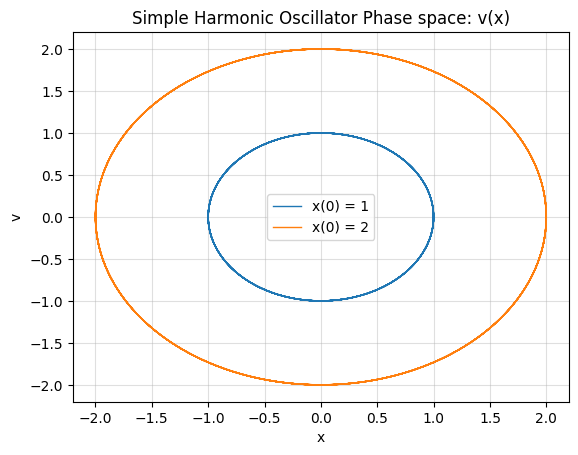

In [9]:
# 4d

omega = 1.0
def f(t, r):
    x, v = r
    return [v, -omega**2 * x]

t_eval = np.linspace(0, 50, 50000)

sol2 = scipy.integrate.solve_ivp(f, [0, 50], [2.0, 0.0], t_eval=t_eval, dense_output=True, method="RK45")

plt.figure()
plt.plot(sol.y[0], sol.y[1], lw=1, label='x(0) = 1')
plt.plot(sol2.y[0], sol2.y[1], lw=1, label='x(0) = 2')
plt.xlabel('x')
plt.ylabel('v')
plt.title('Simple Harmonic Oscillator Phase space: v(x)')
plt.grid(True, alpha=0.4)
plt.legend()
plt.show()

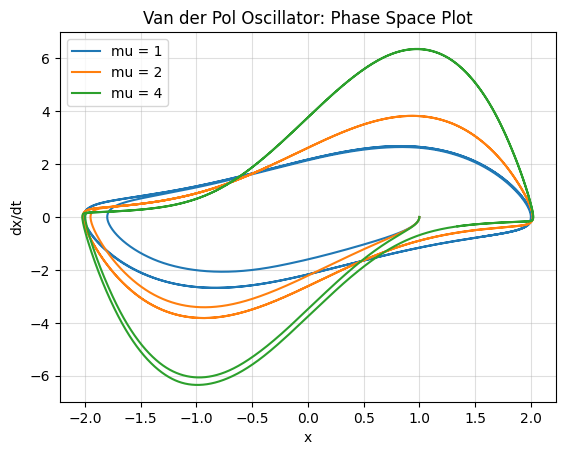

In [10]:
# 4e

omega = 1.0

# dx/dt = v
# dv/dt = mu*(1 - x^2)*v - omega^2*x
def van_der_pol(t, r, mu):
    x, v = r
    dxdt = v
    dvdt = mu*(1 - x**2)*v - omega**2*x
    return [dxdt, dvdt]

t_eval = np.linspace(0, 20, 1000000)
r0 = [1.0, 0.0]

mu_values = [1, 2, 4]

plt.figure()

for mu in mu_values:
    sol = scipy.integrate.solve_ivp(van_der_pol, [0, 20], r0, t_eval=t_eval, args=(mu,))
    plt.plot(sol.y[0], sol.y[1], label=f'mu = {mu}')

plt.xlabel('x')
plt.ylabel('dx/dt')
plt.title('Van der Pol Oscillator: Phase Space Plot')
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

# Problem 5

### 5a

We are given two second order ODEs:

$$\frac{d^2x}{dt^2} = -GM\frac{x}{r^3}, \qquad \frac{d^2y}{dt^2} = -GM\frac{y}{r^3}$$

where $r = \sqrt{x^2 + y^2}$.

We introduce the velocities $v_x = dx/dt$ and $v_y = dy/dt$ to reduce each second order equation into two first order ones. This gives us four coupled first order ODEs:

$$\frac{dx}{dt} = v_x$$

$$\frac{dy}{dt} = v_y$$

$$\frac{dv_x}{dt} = -GM\frac{x}{r^3}$$

$$\frac{dv_y}{dt} = -GM\frac{y}{r^3}$$

The state vector is $\mathbf{r} = (x, y, v_x, v_y)$ and we march this forward in time using RK4.

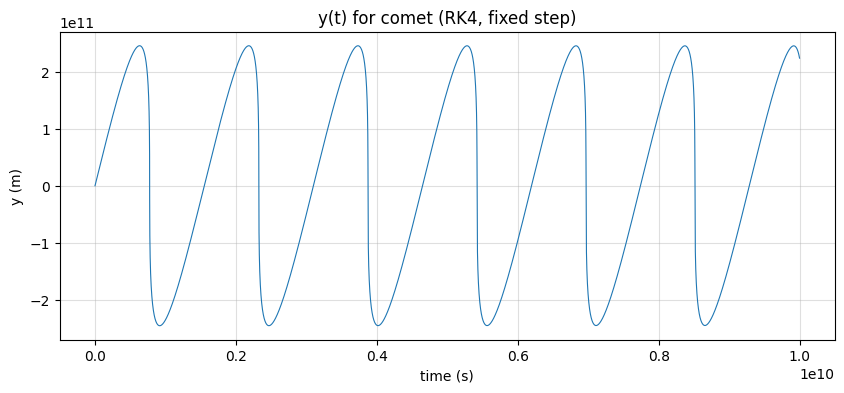

 So we are plotting for multiple orbits of the comet


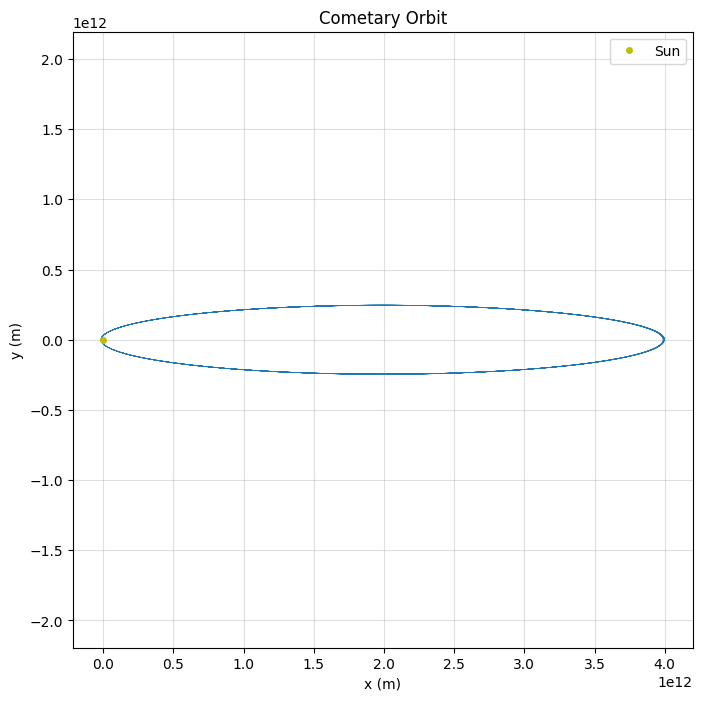

Fixed step: h = 20000 s, total steps = 500001


In [11]:
# 5b

G = 6.674e-11       # gravitational constant
M = 1.989e30        # mass of Sun in kg

# Initial conditions
x0  =  4e12         # 4 billion km in meters
y0  =  0.0
vx0 =  0.0
vy0 =  500.0        # m/s

def f(r, t):
    x, y, vx, vy = r
    rad3 = (x**2 + y**2)**1.5
    ax = -G * M * x / rad3
    ay = -G * M * y / rad3
    return np.array([vx, vy, ax, ay])


def rk4_fixed(f, r0, t_start, t_end, h):
    t_vals = [t_start]
    r_vals = [r0]
    t = t_start
    r = r0.copy()

    while t < t_end:
        k1 = h * f(r,t)
        k2 = h * f(r + k1/2, t + h/2)
        k3 = h * f(r + k2/2, t + h/2)
        k4 = h * f(r + k3, t + h)
        r = r + (k1 + 2*k2 + 2*k3 + k4) / 6
        t = t + h

        t_vals.append(t)
        r_vals.append(r.copy())

    return np.array(t_vals), np.array(r_vals)

r0 = np.array([x0, y0, vx0, vy0])

h_fixed  = 20000
t_end    = 10000000000

t_fixed, r_fixed = rk4_fixed(f, r0, 0.0, t_end, h_fixed)

plt.figure(figsize=(10, 4))
plt.plot(t_fixed, r_fixed[:, 1], lw=0.8)

plt.xlabel('time (s)')
plt.ylabel('y (m)')
plt.title('y(t) for comet (RK4, fixed step)')
plt.grid(True, alpha=0.4)
plt.show()

print(' So we are plotting for multiple orbits of the comet')

plt.figure(figsize=(8, 8))
plt.plot(r_fixed[:, 0], r_fixed[:, 1], lw=0.5)
plt.plot(0, 0, 'yo', markersize=4, label='Sun')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Cometary Orbit')
plt.legend()
plt.axis('equal')
plt.grid(True, alpha=0.4)
plt.show()

print(f'Fixed step: h = {h_fixed} s, total steps = {len(t_fixed)}')

For larger value of h, comet is spiraling inwards. i.e. our system is losing energy due to truncation errors.   
For above computation, h  = 20000s (~5.56 hrs).  
We run the simulation for T = 10000000000s (~317 yrs).  
During this intervel we track the comet for 6 orbits.   
As for our used value of h, the orbits visually overlap we can say that this is a good choice.          

This program runs in 12 seconds

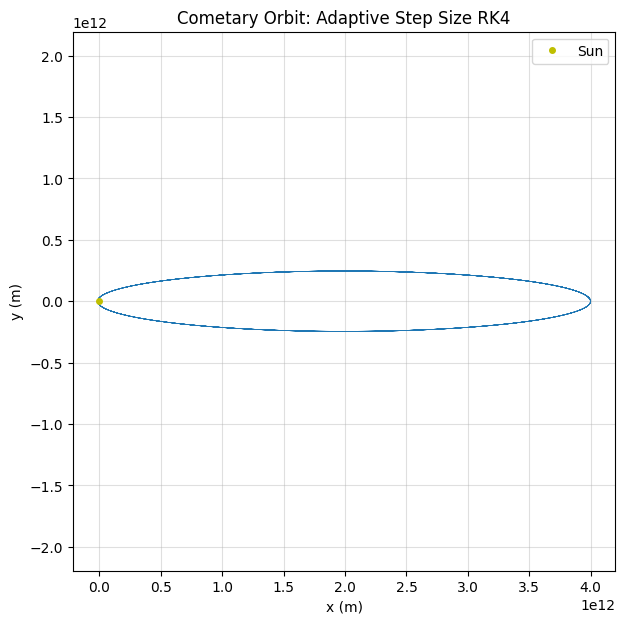

Adaptive step: total steps = 2679


In [12]:
# 5c

def rk4_adaptive(f, r0, t_start, t_end, h, delta):
    t_vals = [t_start]
    r_vals = [r0]
    t = t_start
    r = r0.copy()

    while t < t_end:
        # Two steps of size h
        k1 = h * f(r,t)
        k2 = h * f(r + k1/2, t + h/2)
        k3 = h * f(r + k2/2, t + h/2)
        k4 = h * f(r + k3, t + h)
        r1_mid = r + (k1 + 2*k2 + 2*k3 + k4) / 6

        k1 = h * f(r1_mid, t + h)
        k2 = h * f(r1_mid + k1/2, t + h + h/2)
        k3 = h * f(r1_mid + k2/2, t + h + h/2)
        k4 = h * f(r1_mid + k3, t + 2*h)
        x1 = r1_mid + (k1 + 2*k2 + 2*k3 + k4) / 6

        # One step of size 2h
        h2 = 2 * h
        k1 = h2 * f(r,t)
        k2 = h2 * f(r + k1/2, t + h2/2)
        k3 = h2 * f(r + k2/2, t + h2/2)
        k4 = h2 * f(r + k3, t + h2)
        x2 = r + (k1 + 2*k2 + 2*k3 + k4) / 6

        # Error estimate (position components only)
        eps = np.sqrt((x1[0] - x2[0])**2 + (x1[1] - x2[1])**2) / 30.0

        # Target error per unit time
        target = delta * 2 * h   # delta in m/s * time interval

        if eps == 0:
            rho = 2.0
        else:
            rho = target / eps

        if rho >= 1:
            # Accept the step
            r = x1
            t = t + 2 * h
            t_vals.append(t)
            r_vals.append(r.copy())

        # Adjust step size
        h = h * min(rho**0.25, 2.0)

    return np.array(t_vals), np.array(r_vals)

# delta = 1 km/year = 1000 / (365.25*24*3600) m/s
delta = 1000.0 / (365.25 * 24 * 3600)

t_adapt, r_adapt = rk4_adaptive(f, r0, 0.0, t_end, h_fixed, delta)

plt.figure(figsize=(7, 7))
plt.plot(r_adapt[:, 0], r_adapt[:, 1], lw=0.5)
plt.plot(0, 0, 'yo', markersize=4, label='Sun')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Cometary Orbit: Adaptive Step Size RK4')
plt.legend()
plt.axis('equal')
plt.grid(True, alpha=0.4)
plt.show()

print(f'Adaptive step: total steps = {len(t_adapt)}')




Thus we see that this method does the calculation much faster. It returns the output in 0.3 seconds. Thus is is ~360 times faster that the fixed step size method. We also see that the total steps are just 2679 which is much smaller than the 5,00,000 steps required earlier to do the computation correctly. This is because far away from the sun it is not required to have such a small time step (h = 20,000 s) but nearer to sun it is required. This program keeps the time step h to be small when it is near to the sun (it keeps it 20,0000 s only) but h is very large for orbits far from the sun. Thus this method is almost as accurate as the first, but also much more faster. 

We can quantify this accuracy by computing the fractional energy lost in both cases, which is done below

In [13]:
# Fractional Energy Change

M = 1.989e30
m_comet = 1.0  # mass cancels out in fractional energy, set to 1

def total_energy(r):
    x, y, vx, vy = r
    rad = np.sqrt(x**2 + y**2)
    KE = 0.5 * (vx**2 + vy**2)
    PE = -G * M / rad
    return KE + PE

# Initial energy
E0 = total_energy(r_fixed[0])

# Final energy for fixed step
E_fixed_final = total_energy(r_fixed[-1])
frac_fixed = abs((E_fixed_final - E0) / E0)

# Final energy for adaptive step
E_adapt_final = total_energy(r_adapt[-1])
frac_adapt = abs((E_adapt_final - E0) / E0)

print(f'Initial energy:                    {E0:.6e} J/kg')
print(f'Fixed step  - final energy:        {E_fixed_final:.6e} J/kg')
print(f'Fixed step  - fractional change:   {frac_fixed:.6e}')
print(f'Adaptive    - final energy:        {E_adapt_final:.6e} J/kg')
print(f'Adaptive    - fractional change:   {frac_adapt:.6e}')

Initial energy:                    -3.306146e+07 J/kg
Fixed step  - final energy:        -3.315545e+07 J/kg
Fixed step  - fractional change:   2.842685e-03
Adaptive    - final energy:        -3.306144e+07 J/kg
Adaptive    - fractional change:   8.197452e-07


Therefore we also see that in addition to being faster, adaptive method is much more accurate also. This is because a lot less truncations are made in the adaptive method as just 2800 steps are considered. 

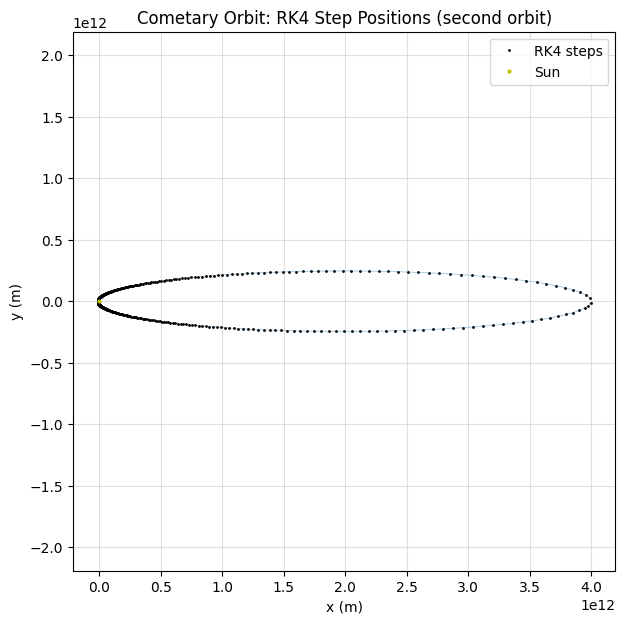

In [14]:
# 5d

# Find crossings where y goes from negative to positive
crossings = []
for i in range(1, len(r_adapt)):
    if r_adapt[i-1, 1] < 0 and r_adapt[i, 1] >= 0 and t_adapt[i] > 1e6:
        crossings.append(i)
        if len(crossings) == 2:
            break

# Ensure we found two crossings
if len(crossings) < 2:
    raise ValueError("Could not detect two full orbits.")

first_orbit_end = crossings[0]
second_orbit_end = crossings[1]

# Plot second orbit (i.e., from end of first to end of second)
plt.figure(figsize=(7, 7))
plt.plot(r_adapt[first_orbit_end:second_orbit_end, 0],
         r_adapt[first_orbit_end:second_orbit_end, 1],
         lw=0.5, alpha=0.5)

plt.plot(r_adapt[first_orbit_end:second_orbit_end, 0],
         r_adapt[first_orbit_end:second_orbit_end, 1],
         'k.', markersize=2, label='RK4 steps')

plt.plot(0, 0, 'yo', markersize=2, label='Sun')

plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Cometary Orbit: RK4 Step Positions (second orbit)')
plt.legend()
plt.axis('equal')
plt.grid(True, alpha=0.4)
plt.show()

# Problem 6

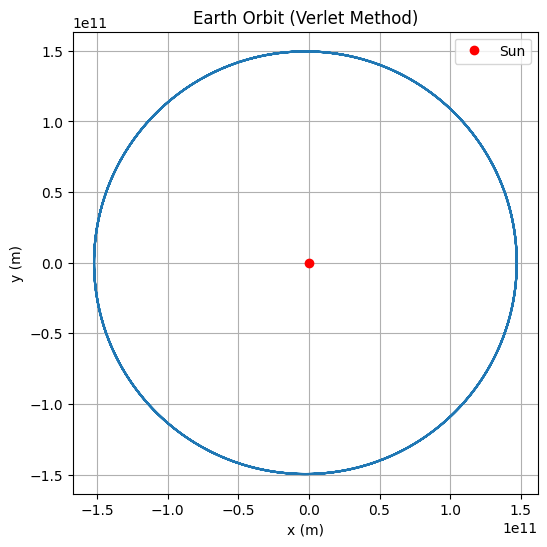

In [15]:
# 6a

G = 6.6738e-11
M = 1.9891e30

x0 = 1.4710e11
y0 = 0.0
vx0 = 0.0
vy0 = 3.0287e4

h = 3600.0 # Time step: 1 hour
t_end = 5 * 365.25 * 24 * 3600 # Total time: 5 years
N = int(t_end / h)

x = np.zeros(N)
y = np.zeros(N)
vx = np.zeros(N)
vy = np.zeros(N)

x[0], y[0] = x0, y0
vx[0], vy[0] = vx0, vy0

def acceleration(x, y):
    r = np.sqrt(x**2 + y**2)
    ax = -G * M * x / r**3
    ay = -G * M * y / r**3
    return ax, ay

ax, ay = acceleration(x[0], y[0]) # Initial acceleration

# Verlet loop
for i in range(N-1):
    x[i+1] = x[i] + vx[i]*h + 0.5*ax*h**2
    y[i+1] = y[i] + vy[i]*h + 0.5*ay*h**2

    ax_new, ay_new = acceleration(x[i+1], y[i+1])

    vx[i+1] = vx[i] + 0.5*(ax + ax_new)*h
    vy[i+1] = vy[i] + 0.5*(ay + ay_new)*h

    ax, ay = ax_new, ay_new

plt.figure(figsize=(6,6))
plt.plot(x, y)
plt.plot(0, 0, 'ro', label='Sun')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Earth Orbit (Verlet Method)')
plt.axis('equal')
plt.legend()
plt.grid()
plt.show()

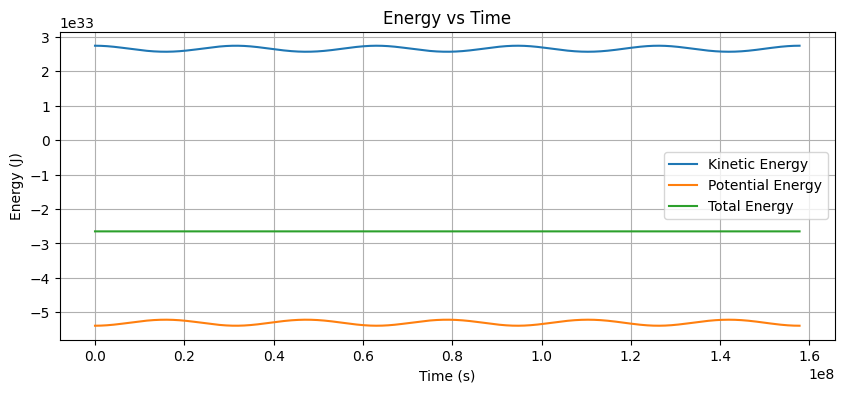

In [16]:
# 6b

m = 5.9722e24

KE = 0.5 * m * (vx**2 + vy**2)
r = np.sqrt(x**2 + y**2)
PE = -G * M * m / r
E = KE + PE

t = np.arange(N) * h

plt.figure(figsize=(10,4))
plt.plot(t, KE, label='Kinetic Energy')
plt.plot(t, PE, label='Potential Energy')
plt.plot(t, E, label='Total Energy')
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Energy (J)')
plt.title('Energy vs Time')
plt.grid()
plt.show()

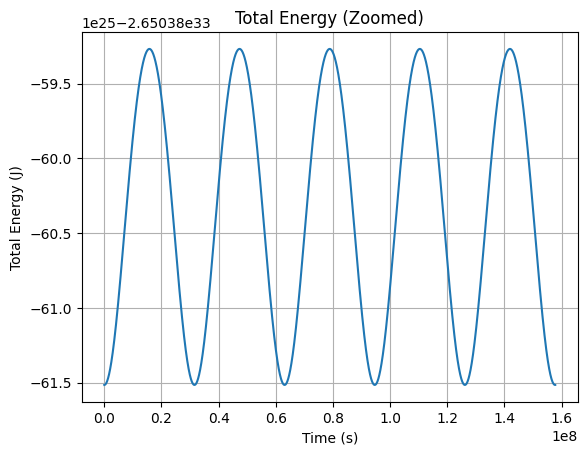

In [17]:
# 6c

plt.figure()
plt.plot(t, E)
plt.xlabel('Time (s)')
plt.ylabel('Total Energy (J)')
plt.title('Total Energy (Zoomed)')
plt.grid()
plt.show()

# Problem 7

### 7a

The time-independent Schrödinger equation with a harmonic potential $V(x) = V_0 x^2 / a^2$ is:

$$-\frac{\hbar^2}{2m}\frac{d^2\psi}{dx^2} + \frac{V_0 x^2}{a^2}\psi = E\psi$$

Rearranging:

$$\frac{d^2\psi}{dx^2} = \frac{2m}{\hbar^2}\left(\frac{V_0 x^2}{a^2} - E\right)\psi$$

We introduce $\phi = d\psi/dx$ to reduce this to two first order ODEs:

$$\frac{d\psi}{dx} = \phi$$

$$\frac{d\phi}{dx} = \frac{2m}{\hbar^2}\left(\frac{V_0 x^2}{a^2} - E\right)\psi$$

This is an **eigenvalue problem**! Solutions satisfying the boundary conditions $\psi = 0$ at $x = \pm 10a$ exist only for specific values of $E$. We use the **shooting method**: fix $\psi(-10a) = 0$, $\phi(-10a) = 1$, integrate to $x = +10a$, and search for values of $E$ where $\psi(+10a) = 0$ using the secant method.

In [18]:
hbar = 1.0546e-34
m    = 9.109e-31
V0   = 50 * 1.6e-19
a    = 1e-11

x_start = -10 * a
x_end   =  10 * a
N       = 1000
h       = (x_end - x_start) / N

# RHS of the two first order ODEs
def f(r, x, E):
    psi, phi = r
    dpsi = phi
    dphi = (2*m/hbar**2) * (V0*x**2/a**2 - E) * psi
    return np.array([dpsi, dphi])

# Shoot from x_start to x_end using RK4, return psi at x_end
def shoot(E):
    r = np.array([0.0, 1.0])  # psi(-10a) = 0, dpsi/dx = 1
    x = x_start
    for _ in range(N):
        k1 = h * f(r,x, E)
        k2 = h * f(r + k1/2, x + h/2, E)
        k3 = h * f(r + k2/2, x + h/2, E)
        k4 = h * f(r + k3, x + h, E)
        r  = r + (k1 + 2*k2 + 2*k3 + k4) / 6
        x  = x + h
    return r[0]  # psi at x_end

# Secant method to find eigenvalue
def find_eigenvalue(E1, E2, tol=1e-3*1.6e-19):
    psi1 = shoot(E1)
    psi2 = shoot(E2)
    while abs(E2 - E1) > tol:
        E3   = E2 - psi2 * (E2 - E1) / (psi2 - psi1)
        E1, psi1 = E2, psi2
        E2, psi2 = E3, shoot(E3)
    return E2

# Scan over E and find sign changes
E_scan  = np.linspace(100*1.6e-19, 1000*1.6e-19, 500)
psi_end = np.array([shoot(E) for E in E_scan])

eigenvalues = []
for i in range(len(psi_end) - 1):
    if psi_end[i] * psi_end[i+1] < 0:
        E_eig = find_eigenvalue(E_scan[i], E_scan[i+1])
        eigenvalues.append(E_eig)
    if len(eigenvalues) == 3:
        break

print("Ground state and first two excited state energies:")
for n, E in enumerate(eigenvalues):
    print(f'  E_{n} = {E/1.6e-19:.3f} eV')

print(f'\nE_1 - E_0 = {(eigenvalues[1] - eigenvalues[0])/1.6e-19:.3f} eV')
print(f'E_2 - E_1 = {(eigenvalues[2] - eigenvalues[1])/1.6e-19:.3f} eV')
print('Energy levels are equally spaced as expected for a harmonic oscillator.')

Ground state and first two excited state energies:
  E_0 = 138.122 eV
  E_1 = 414.366 eV
  E_2 = 690.609 eV

E_1 - E_0 = 276.244 eV
E_2 - E_1 = 276.244 eV
Energy levels are equally spaced as expected for a harmonic oscillator.


In [19]:
# 7b

# RHS with anharmonic potential V(x) = V0 * x^4 / a^4
def f(r, x, E):
    psi, phi = r
    dpsi = phi
    dphi = (2*m/hbar**2) * (V0*x**4/a**4 - E) * psi
    return np.array([dpsi, dphi])

def shoot(E):
    r = np.array([0.0, 1.0])
    x = x_start
    for _ in range(N):
        k1 = h * f(r, x, E)
        k2 = h * f(r + k1/2, x + h/2, E)
        k3 = h * f(r + k2/2, x + h/2, E)
        k4 = h * f(r + k3, x + h, E)
        r  = r + (k1 + 2*k2 + 2*k3 + k4) / 6
        x  = x + h
    return r[0]

def find_eigenvalue(E1, E2, tol=1e-3*1.6e-19):
    psi1 = shoot(E1)
    psi2 = shoot(E2)
    while abs(E2 - E1) > tol:
        E3   = E2 - psi2 * (E2 - E1) / (psi2 - psi1)
        E1, psi1 = E2, psi2
        E2, psi2 = E3, shoot(E3)
    return E2

E_scan  = np.linspace(10*1.6e-19, 2000*1.6e-19, 500)
psi_end = np.array([shoot(E) for E in E_scan])

eigenvalues = []
for i in range(len(psi_end) - 1):
    if psi_end[i] * psi_end[i+1] < 0:
        E_eig = find_eigenvalue(E_scan[i], E_scan[i+1])
        eigenvalues.append(E_eig)
    if len(eigenvalues) == 3:
        break

print("Anharmonic oscillator - ground state and first two excited state energies:")
for n, E in enumerate(eigenvalues):
    print(f'  E_{n} = {E/1.6e-19:.3f} eV')

print(f'\nE_1 - E_0 = {(eigenvalues[1] - eigenvalues[0])/1.6e-19:.3f} eV')
print(f'E_2 - E_1 = {(eigenvalues[2] - eigenvalues[1])/1.6e-19:.3f} eV')
print('Unlike the harmonic oscillator, energy levels are NOT equally spaced.')

Anharmonic oscillator - ground state and first two excited state energies:
  E_0 = 205.501 eV
  E_1 = 736.387 eV
  E_2 = 1444.935 eV

E_1 - E_0 = 530.886 eV
E_2 - E_1 = 708.548 eV
Unlike the harmonic oscillator, energy levels are NOT equally spaced.


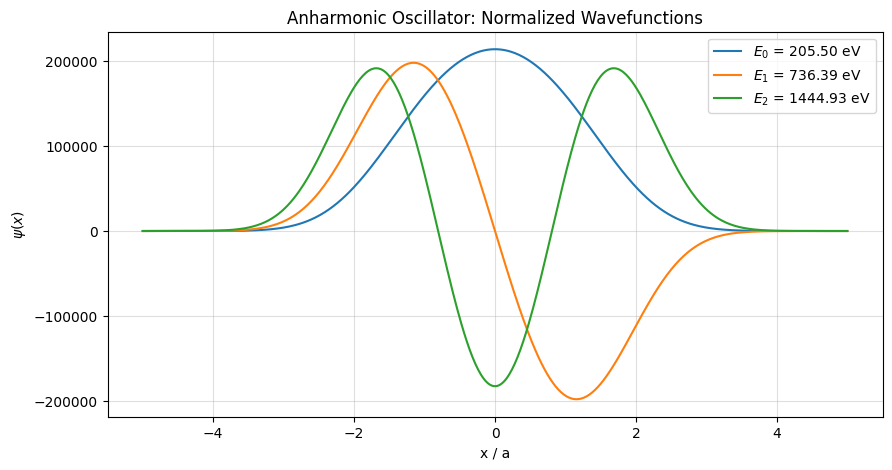

In [20]:
#7c

x_vals  = np.linspace(x_start, x_end, N+1)

# RHS with anharmonic potential
def f(r, x, E):
    psi, phi = r
    dpsi = phi
    dphi = (2*m/hbar**2) * (V0*x**4/a**4 - E) * psi
    return np.array([dpsi, dphi])

# Full wavefunction using RK4
def get_wavefunction(E):
    r    = np.array([0.0, 1.0])
    x    = x_start
    psis = [r[0]]
    for _ in range(N):
        k1 = h * f(r,x,E)
        k2 = h * f(r + k1/2, x + h/2, E)
        k3 = h * f(r + k2/2, x + h/2, E)
        k4 = h * f(r + k3, x + h, E)
        r  = r + (k1 + 2*k2 + 2*k3 + k4) / 6
        x  = x + h
        psis.append(r[0])
    return np.array(psis)

def shoot(E):
    return get_wavefunction(E)[-1]

def find_eigenvalue(E1, E2, tol=1e-3*1.6e-19):
    psi1 = shoot(E1)
    psi2 = shoot(E2)
    while abs(E2 - E1) > tol:
        E3   = E2 - psi2 * (E2 - E1) / (psi2 - psi1)
        E1, psi1 = E2, psi2
        E2, psi2 = E3, shoot(E3)
    return E2

# Find eigenvalues
E_scan  = np.linspace(10*1.6e-19, 2000*1.6e-19, 500)
psi_end = np.array([shoot(E) for E in E_scan])

eigenvalues = []
for i in range(len(psi_end) - 1):
    if psi_end[i] * psi_end[i+1] < 0:
        E_eig = find_eigenvalue(E_scan[i], E_scan[i+1])
        eigenvalues.append(E_eig)
    if len(eigenvalues) == 3:
        break

# Normalize wavefunctions using left half only (avoids large spurious values at boundaries)
plt.figure(figsize=(10, 5))

for n, E in enumerate(eigenvalues):
    psi = get_wavefunction(E)

    # Use left half for normalization
    mid  = len(psi) // 2
    norm = 2 * np.trapezoid(psi[:mid]**2, x_vals[:mid])
    psi  = psi / np.sqrt(norm)

    # Plot over x = -5a to 5a
    mask = (x_vals >= -5*a) & (x_vals <= 5*a)
    plt.plot(x_vals[mask]/a, psi[mask], label=f'$E_{n}$ = {E/1.6e-19:.2f} eV')

plt.xlabel('x / a')
plt.ylabel(r'$\psi(x)$')
plt.title('Anharmonic Oscillator: Normalized Wavefunctions')
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()



The large values at the ends of the wavefunction array are **spurious** i.e. they are not physical. They arise because for an arbitrary value of $E$ that is not exactly an eigenvalue, the wavefunction solution does not decay to zero at the boundaries but instead diverges exponentially. Even at the correct eigenvalue, small numerical errors accumulate over the integration and cause the wavefunction to blow up near $x = +10a$.

The shooting is done **left to right**: we start at $x = -10a$ where we enforce $\psi = 0$ as the initial condition. So the left boundary is always correct by construction. The right end $x = +10a$ is where the numerical error has accumulated after integrating across the entire domain, so that is where the blowup is worst.

The left half of the domain is therefore much more reliable. It is close to the starting point and has not yet accumulated significant numerical error. By integrating $|\psi|^2$ only over the left half (from $x = -10a$ to $x = 0$) and doubling the result, we use the cleanest part of the wavefunction and avoid the spurious blowup near $x = +10a$. This works because the anharmonic potential $V(x) = V_0 x^4/a^4$ is symmetric about $x = 0$, so the wavefunctions are either purely even or purely odd, and the integral over the left half equals exactly half the total integral.

# Problem 8

### 8a

The gravitational force on star 1 due to star 2 is:

$$\mathbf{F}_{12} = Gm_1 m_2 \frac{\mathbf{r}_2 - \mathbf{r}_1}{|\mathbf{r}_2 - \mathbf{r}_1|^3}$$

and similarly for the force due to star 3. By Newton's second law, the equation of motion for star 1 is:

$$m_1 \frac{d^2 \mathbf{r}_1}{dt^2} = Gm_1 m_2 \frac{\mathbf{r}_2 - \mathbf{r}_1}{|\mathbf{r}_2 - \mathbf{r}_1|^3} + Gm_1 m_3 \frac{\mathbf{r}_3 - \mathbf{r}_1}{|\mathbf{r}_3 - \mathbf{r}_1|^3}$$

Canceling $m_1$:

$$\frac{d^2 \mathbf{r}_1}{dt^2} = Gm_2 \frac{\mathbf{r}_2 - \mathbf{r}_1}{|\mathbf{r}_2 - \mathbf{r}_1|^3} + Gm_3 \frac{\mathbf{r}_3 - \mathbf{r}_1}{|\mathbf{r}_3 - \mathbf{r}_1|^3}$$

By symmetry, the equations for stars 2 and 3 are:

$$\frac{d^2 \mathbf{r}_2}{dt^2} = Gm_1 \frac{\mathbf{r}_1 - \mathbf{r}_2}{|\mathbf{r}_1 - \mathbf{r}_2|^3} + Gm_3 \frac{\mathbf{r}_3 - \mathbf{r}_2}{|\mathbf{r}_3 - \mathbf{r}_2|^3}$$

$$\frac{d^2 \mathbf{r}_3}{dt^2} = Gm_1 \frac{\mathbf{r}_1 - \mathbf{r}_3}{|\mathbf{r}_1 - \mathbf{r}_3|^3} + Gm_2 \frac{\mathbf{r}_2 - \mathbf{r}_3}{|\mathbf{r}_2 - \mathbf{r}_3|^3}$$

We now reduce these three second order vector equations (six second order scalar equations) into twelve first order equations by introducing velocities $\mathbf{v}_i = d\mathbf{r}_i/dt$:

$$\frac{d\mathbf{r}_i}{dt} = \mathbf{v}_i, \qquad i = 1, 2, 3$$

$$\frac{d\mathbf{v}_1}{dt} = Gm_2 \frac{\mathbf{r}_2 - \mathbf{r}_1}{|\mathbf{r}_2 - \mathbf{r}_1|^3} + Gm_3 \frac{\mathbf{r}_3 - \mathbf{r}_1}{|\mathbf{r}_3 - \mathbf{r}_1|^3}$$

$$\frac{d\mathbf{v}_2}{dt} = Gm_1 \frac{\mathbf{r}_1 - \mathbf{r}_2}{|\mathbf{r}_1 - \mathbf{r}_2|^3} + Gm_3 \frac{\mathbf{r}_3 - \mathbf{r}_2}{|\mathbf{r}_3 - \mathbf{r}_2|^3}$$

$$\frac{d\mathbf{v}_3}{dt} = Gm_1 \frac{\mathbf{r}_1 - \mathbf{r}_3}{|\mathbf{r}_1 - \mathbf{r}_3|^3} + Gm_2 \frac{\mathbf{r}_2 - \mathbf{r}_3}{|\mathbf{r}_2 - \mathbf{r}_3|^3}$$

The state vector is $\mathbf{s} = (x_1, y_1, x_2, y_2, x_3, y_3, v_{x1}, v_{y1}, v_{x2}, v_{y2}, v_{x3}, v_{y3})$ and we march this forward using an adaptive step size method.

Total adaptive steps taken: 362


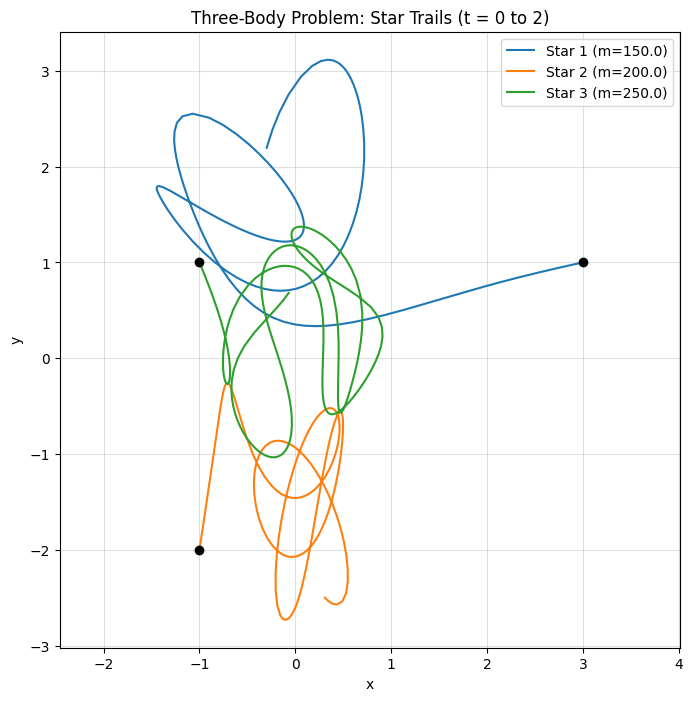

In [21]:
# 8b

G  = 1.0
m1 = 150.0
m2 = 200.0
m3 = 250.0

# State vector: [x1, y1, x2, y2, x3, y3, vx1, vy1, vx2, vy2, vx3, vy3]
def f(t, r):
    x1, y1, x2, y2, x3, y3, vx1, vy1, vx2, vy2, vx3, vy3 = r

    r12 = ((x2-x1)**2 + (y2-y1)**2)**1.5
    r13 = ((x3-x1)**2 + (y3-y1)**2)**1.5
    r23 = ((x3-x2)**2 + (y3-y2)**2)**1.5

    ax1 = G*m2*(x2-x1)/r12 + G*m3*(x3-x1)/r13
    ay1 = G*m2*(y2-y1)/r12 + G*m3*(y3-y1)/r13

    ax2 = G*m1*(x1-x2)/r12 + G*m3*(x3-x2)/r23
    ay2 = G*m1*(y1-y2)/r12 + G*m3*(y3-y2)/r23

    ax3 = G*m1*(x1-x3)/r13 + G*m2*(x2-x3)/r23
    ay3 = G*m1*(y1-y3)/r13 + G*m2*(y2-y3)/r23

    return [vx1, vy1, vx2, vy2, vx3, vy3,
            ax1, ay1, ax2, ay2, ax3, ay3]

r0 = [ 3.0,  1.0,
      -1.0, -2.0,
      -1.0,  1.0,
       0.0,  0.0,
       0.0,  0.0,
       0.0,  0.0]

sol = scipy.integrate.solve_ivp(f, [0, 2], r0, method='RK45', atol=1e-6, rtol=1e-6, dense_output=True) # We make the tolerace 1e-6 to get a more accurate solution. 1e-3 is too large and the solution is not accurate enough to show the correct trajectories of the stars.

print(f"Total adaptive steps taken: {len(sol.t)}")

x1 = sol.y[0];  y1 = sol.y[1]
x2 = sol.y[2];  y2 = sol.y[3]
x3 = sol.y[4];  y3 = sol.y[5]

plt.figure(figsize=(8, 8))
plt.plot(x1, y1, label=f'Star 1 (m={m1})')
plt.plot(x2, y2, label=f'Star 2 (m={m2})')
plt.plot(x3, y3, label=f'Star 3 (m={m3})')
plt.plot([x1[0], x2[0], x3[0]], [y1[0], y2[0], y3[0]], 'ko', markersize=6)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Three-Body Problem: Star Trails (t = 0 to 2)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.axis('equal')
plt.show()